In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf

print("Версия TensorFlow:", tf.__version__)
print("Доступные GPU:", tf.config.list_physical_devices('GPU'))
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[0], 'GPU')

Версия TensorFlow: 2.21.0
Доступные GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B0, preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger,
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTO = tf.data.AUTOTUNE

DATA_DIR = Path("/home/sm/Desktop/ml/CarBrandClassificationDataset")

EPOCHS_WARMUP = 12
EPOCHS_FINETUNE = 24

AUTO = tf.data.AUTOTUNE

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## 1. Загрузка структуры датасета

Ожидается структура:

```text
CarBrandClassificationDataset/
├── train/
│   ├── class_1/
│   └── ...
├── val/
│   ├── class_1/
│   └── ...
└── test/
    ├── class_1/
    └── ...
```

В таблицы ниже собираются пути к изображениям и строковые метки классов.

In [5]:
train_base = DATA_DIR / "train"
val_base = DATA_DIR / "val"
test_base = DATA_DIR / "test"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def build_split_df(split_dir: Path) -> pd.DataFrame:
    """Собирает таблицу path/label для одного split'а."""
    if not split_dir.exists():
        raise FileNotFoundError(f"Папка split'а не найдена: {split_dir}")

    rows = []
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    for cls_dir in class_dirs:
        cls = cls_dir.name
        for f in cls_dir.rglob("*"):
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append((str(f), cls))
    return pd.DataFrame(rows, columns=["path", "label"])

df_train = build_split_df(train_base)
df_val = build_split_df(val_base)
df_test = build_split_df(test_base)

print("Количество изображений:")
print("Train:", len(df_train), "| классов:", df_train["label"].nunique())
print("Val  :", len(df_val), "| классов:", df_val["label"].nunique())
print("Test :", len(df_test), "| классов:", df_test["label"].nunique())

display(pd.concat({
    "train": df_train["label"].value_counts().sort_index(),
    "val": df_val["label"].value_counts().sort_index(),
    "test": df_test["label"].value_counts().sort_index(),
}, axis=1).fillna(0).astype(int).head())

Количество изображений:
Train: 11517 | классов: 33
Val  : 2475 | классов: 33
Test : 2475 | классов: 33


,train,val,test
label,,,
Acura,349,75,75
Aston Martin,349,75,75
Audi,349,75,75
BMW,349,75,75
Bentley,349,75,75


In [6]:
# Единое отображение классов в индексы.
classes = sorted(df_train["label"].unique().tolist())
class2idx = {c: i for i, c in enumerate(classes)}
idx2class = {i: c for c, i in class2idx.items()}
num_classes = len(classes)

for name, df in [("val", df_val), ("test", df_test)]:
    missing = set(df["label"].unique()) - set(classes)
    if missing:
        raise ValueError(f"В {name} есть классы, которых нет в train: {sorted(missing)}")

df_train["label_idx"] = df_train["label"].map(class2idx)
df_val["label_idx"] = df_val["label"].map(class2idx)
df_test["label_idx"] = df_test["label"].map(class2idx)

print("Число классов:", num_classes)
print("Пример отображения:", list(class2idx.items())[:10])
df_train.head()

Число классов: 33
Пример отображения: [('Acura', 0), ('Aston Martin', 1), ('Audi', 2), ('BMW', 3), ('Bentley', 4), ('Buick', 5), ('Cadillac', 6), ('Chevrolet', 7), ('Chrysler', 8), ('Dodge', 9)]


,path,label,label_idx
0,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
1,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
2,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
3,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
4,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0


## 2. Распределение изображений по классам

равномерное распределение по всем классам

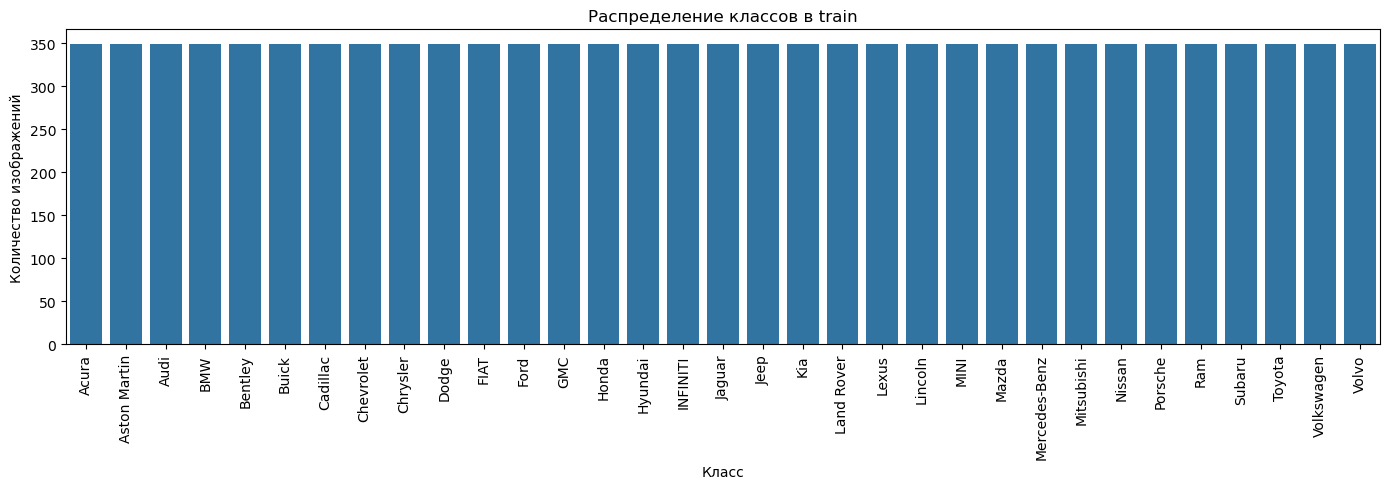

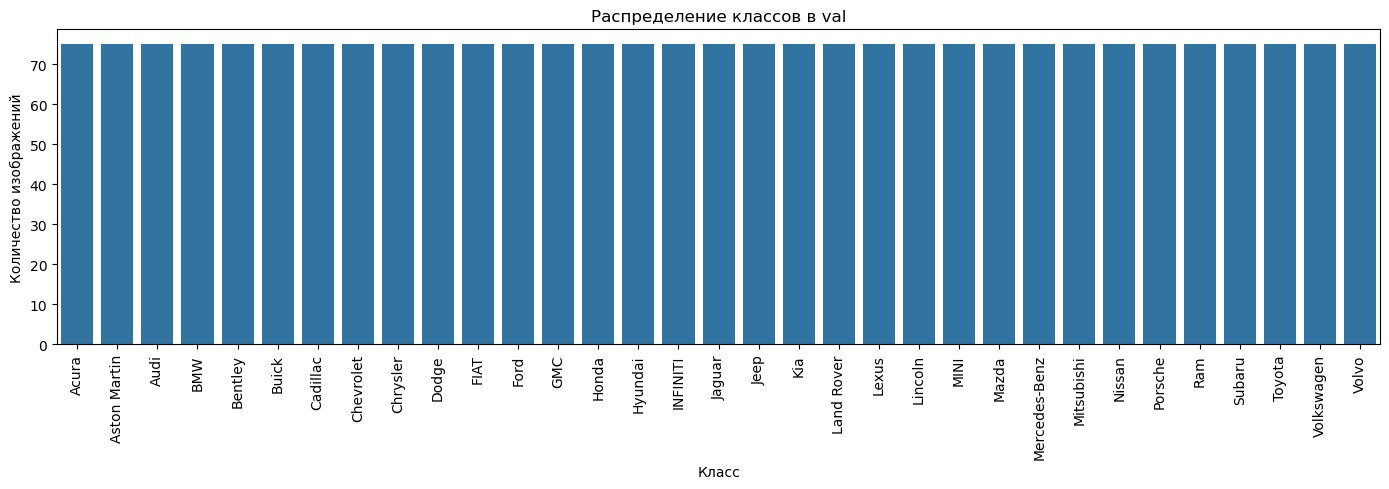

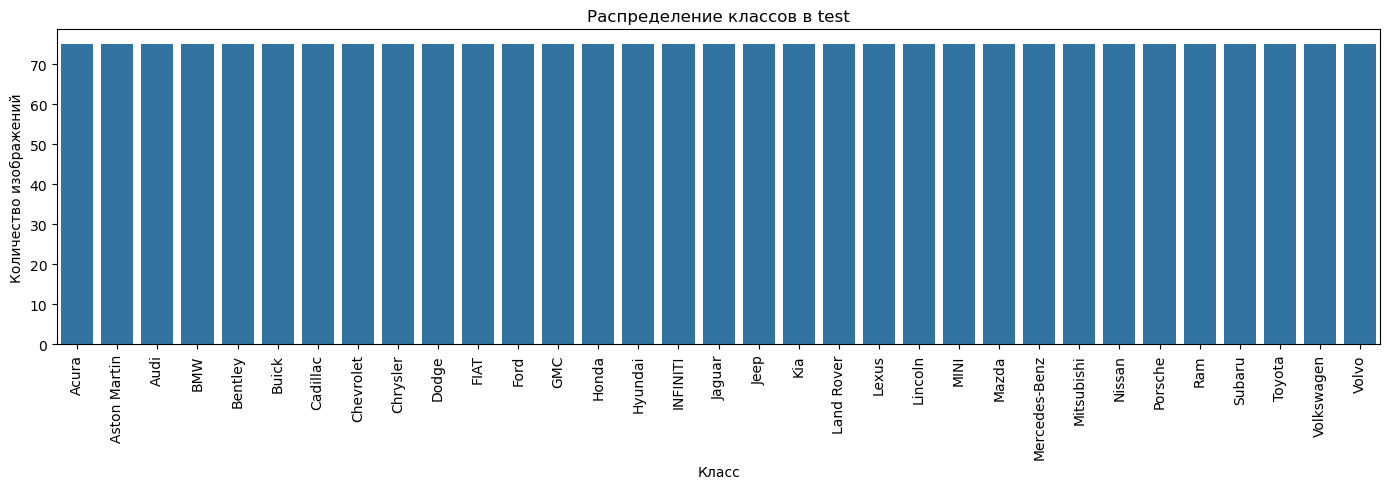

Коэффициент дисбаланса train max/min: 1.00


In [7]:
def plot_class_distribution(df: pd.DataFrame, title: str) -> None:
    counts = df["label"].value_counts().sort_values(ascending=False)
    plt.figure(figsize=(14, 5))
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(title)
    plt.xlabel("Класс")
    plt.ylabel("Количество изображений")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

plot_class_distribution(df_train, "Распределение классов в train")
plot_class_distribution(df_val, "Распределение классов в val")
plot_class_distribution(df_test, "Распределение классов в test")

class_counts = df_train["label_idx"].value_counts().sort_index()
imbalance_ratio = class_counts.max() / max(class_counts.min(), 1)
print(f"Коэффициент дисбаланса train max/min: {imbalance_ratio:.2f}")

## 3. `tf.data`-пайплайн и аугментация

Используется resize_with_pad, т.к. для авто критичны пропорции (resize) и нельзя обрезать (crop) - мы рискуем потерять важную часть изображения

Для EfficientNet используется совместимый с ImageNet-предобучением `preprocess_input`(взял из примера, в доках прочитал, что это уже фунция заглушка, функционал встроен в модель).

In [8]:
def decode_image(path):
    """Читает изображение, приводит к RGB, float32 и нужному размеру."""
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize_with_pad(img, IMG_SIZE[0], IMG_SIZE[1])
    return img

augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
], name="augmenter")

def make_ds(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(min(len(paths), 4096), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(lambda x, y: (decode_image(x), y), num_parallel_calls=AUTO)
    ds = ds.cache()

    if augment:
        ds = ds.map(lambda x, y: (augmenter(x, training=True),y), num_parallel_calls=AUTO)

    ds = ds.map(lambda x, y: (preprocess_input(x * 255.0),y),num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTO)

    return ds

train_ds = make_ds(
    df_train["path"].tolist(),
    df_train["label_idx"].tolist(),
    augment=True,
    shuffle=True,
)

val_ds = make_ds(
    df_val["path"].tolist(),
    df_val["label_idx"].tolist(),
)

test_ds = make_ds(
    df_test["path"].tolist(),
    df_test["label_idx"].tolist(),
)

print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## 4. Transfer learning: EfficientNetB0V2

используем предобученную на других данных модель для решения нашей задачи

сначала подбор гиперпараметров, нормальный gridsearch строить не стал, потому что этот полчаса отрабатывал полный перебор с нормальным количеством вариаций может и дал бы небольшой прирост, но за сутки ноут бы сдох

In [ ]:
search_space = [

    {
        "dropout": 0.25,
        "dense_units": 128,
        "lr": 3e-4,
    },

    {
        "dropout": 0.35,
        "dense_units": 256,
        "lr": 3e-4,
    },

    {
        "dropout": 0.40,
        "dense_units": 256,
        "lr": 1e-4,
    },

    {
        "dropout": 0.35,
        "dense_units": 512,
        "lr": 3e-4,
    },

    {
        "dropout": 0.4,
        "dense_units": 512,
        "lr": 3e-4,
    },
]

def build_model(dropout,dense_units,lr):
    base_model = EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,),
    )

    base_model.trainable = False

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = base_model(inputs,training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units,activation="relu",)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout * 0.75)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
    )(x)

    model = models.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            "accuracy",
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_acc"),
        ],
    )

    return model

In [10]:
search_results = []

best_model = None
best_val_acc = 0.0

for i, config in enumerate(search_space):

    print("=" * 60)
    print(f"CONFIG {i+1}/{len(search_space)}")
    print(config)

    model_hp = build_model(
        dropout=config["dropout"],
        dense_units=config["dense_units"],
        lr=config["lr"],
    )

    history_hp = model_hp.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=1,
    )

    best_epoch_acc = max(
        history_hp.history["val_accuracy"]
    )

    search_results.append({
        **config,
        "val_accuracy": best_epoch_acc,
    })

    print(f"Best val_accuracy: {best_epoch_acc:.4f}")

    if best_epoch_acc > best_val_acc:
        best_val_acc = best_epoch_acc
        best_model = model_hp

print("\nBEST VAL ACC:", best_val_acc)

CONFIG 1/5
{'dropout': 0.25, 'dense_units': 128, 'lr': 0.0003}
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 72s 136ms/step - accuracy: 0.0710 - loss: 3.8098 - top5_acc: 0.2519 - val_accuracy: 0.1240 - val_loss: 3.2274 - val_top5_acc: 0.3588
Epoch 2/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.1178 - loss: 3.3541 - top5_acc: 0.3550 - val_accuracy: 0.1543 - val_loss: 3.0768 - val_top5_acc: 0.4376
Epoch 3/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.1526 - loss: 3.1791 - top5_acc: 0.4091 - val_accuracy: 0.1826 - val_loss: 2.9540 - val_top5_acc: 0.4857
Epoch 4/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.1758 - loss: 3.0457 - top5_acc: 0.4545 - val_accuracy: 0.2020 - val_loss: 2.8645 - val_top5_acc: 0.5143
Epoch 5/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.1981 - loss: 2.9346 - top5_acc: 0.4982 - val_accuracy: 0.2246 - val_loss: 2.7997 - val_top5_acc: 0.5422
Best val_accuracy: 0.2246
CONF

In [11]:
results_hp_df = pd.DataFrame(
    search_results
)

results_hp_df = results_hp_df.sort_values(
    by="val_accuracy",
    ascending=False,
)

results_hp_df

,dropout,dense_units,lr,val_accuracy
3,0.35,512,0.0003,0.269495
4,0.40,512,0.0003,0.260606
1,0.35,256,0.0003,0.243232
0,0.25,128,0.0003,0.224646
2,0.40,256,0.0001,0.183434


In [12]:
best_config = results_hp_df.iloc[0]
best_config

dropout           0.350000
dense_units     512.000000
lr                0.000300
val_accuracy      0.269495
Name: 3, dtype: float64

забил параметры руками, чтобы спокойно перезапускать

In [ ]:
def build_efficientnet(num_classes: int, img_size=IMG_SIZE, dropout=0.35, dense_units=512) -> tuple[tf.keras.Model, tf.keras.Model]:
    base = EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_shape=(*img_size, 3),
    )
    base.trainable = False

    inputs = layers.Input(shape=(*img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout * 0.75)(x)

    logits = layers.Dense(num_classes)(x)
    outputs = layers.Activation("softmax", dtype="float32")(logits)

    model = models.Model(inputs, outputs, name="efficientnetb0_car_brand")
    return model, base

def compile_model(model: tf.keras.Model, lr: float) -> None:
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy"),
        ],
    )

model_tl, base = build_efficientnet(num_classes)
compile_model(model_tl, lr=3e-4)
model_tl.summary()

Model: "efficientnetb0_car_brand"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │        16,929 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 33)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,594,161 (25.15 MB)

 Trainable params: 673,825 (2.57 MB)

 Non-trainable params: 5,920,336 (22.58 MB)

обучение классификатора на фиксированных признаках

так как мы используем предобученную модель, то я замораживаю исходные слои, добавил свои и обучаю пока только их

In [10]:
tl_callbacks = [
    ModelCheckpoint(
        "models/effv2b0_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
    CSVLogger("models/effv2b0_training_log.csv", append=False),
]

print("Этап 1: обучение classifier head при замороженном backbone.")
hist_warmup = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_WARMUP,
    callbacks=tl_callbacks,
)

Этап 1: обучение classifier head при замороженном backbone.
Epoch 1/12
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.0996 - loss: 3.8557 - top3_accuracy: 0.2130 - top5_accuracy: 0.3031
Epoch 1: val_accuracy improved from None to 0.15030, saving model to models/effv2b0_best.keras

Epoch 1: finished saving model to models/effv2b0_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 71s 134ms/step - accuracy: 0.1256 - loss: 3.6029 - top3_accuracy: 0.2553 - top5_accuracy: 0.3529 - val_accuracy: 0.1503 - val_loss: 3.0981 - val_top3_accuracy: 0.3184 - val_top5_accuracy: 0.4356 - learning_rate: 3.0000e-04
Epoch 2/12
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1798 - loss: 3.1145 - top3_accuracy: 0.3561 - top5_accuracy: 0.4613
Epoch 2: val_accuracy improved from 0.15030 to 0.20485, saving model to models/effv2b0_best.keras

Epoch 2: finished saving model to models/effv2b0_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.1965 - loss: 3.0541 - top3_accuracy: 0.3726 - 

fine-tuning - разморозил часть исходных слоев, для дообучения

In [11]:
def set_fine_tuning(base_model: tf.keras.Model, fine_tune_layers: int) -> None:
    """Размораживает последние fine_tune_layers слоёв, кроме BatchNormalization."""
    base_model.trainable = True

    for layer in base_model.layers[:-fine_tune_layers]:
        layer.trainable = False

    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

FINE_TUNE_LAYERS = 80
set_fine_tuning(base, fine_tune_layers=FINE_TUNE_LAYERS)

trainable_count = sum(int(layer.trainable) for layer in base.layers)
print(f"Trainable слоёв backbone: {trainable_count} из {len(base.layers)}")

compile_model(model_tl, lr=1e-4)

print("Этап 2: fine-tuning верхних слоёв EfficientNetV2B0.")
hist_ft = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=tl_callbacks,
)

Trainable слоёв backbone: 64 из 270
Этап 2: fine-tuning верхних слоёв EfficientNetV2B0.
Epoch 1/24
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4579 - loss: 1.9306 - top3_accuracy: 0.6746 - top5_accuracy: 0.7693
Epoch 1: val_accuracy improved from 0.37333 to 0.38909, saving model to models/effv2b0_best.keras

Epoch 1: finished saving model to models/effv2b0_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 56s 108ms/step - accuracy: 0.4808 - loss: 1.8452 - top3_accuracy: 0.6962 - top5_accuracy: 0.7893 - val_accuracy: 0.3891 - val_loss: 2.2714 - val_top3_accuracy: 0.6024 - val_top5_accuracy: 0.7002 - learning_rate: 1.0000e-04
Epoch 2/24
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5215 - loss: 1.7065 - top3_accuracy: 0.7302 - top5_accuracy: 0.8195
Epoch 2: val_accuracy improved from 0.38909 to 0.41374, saving model to models/effv2b0_best.keras

Epoch 2: finished saving model to models/effv2b0_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.5300 - loss: 1.

## 7. Графики обучения

Графики позволяют быстро увидеть:

- есть ли переобучение;
- достигла ли модель плато;
- помог ли fine-tuning после warmup;
- не слишком ли большой learning rate.

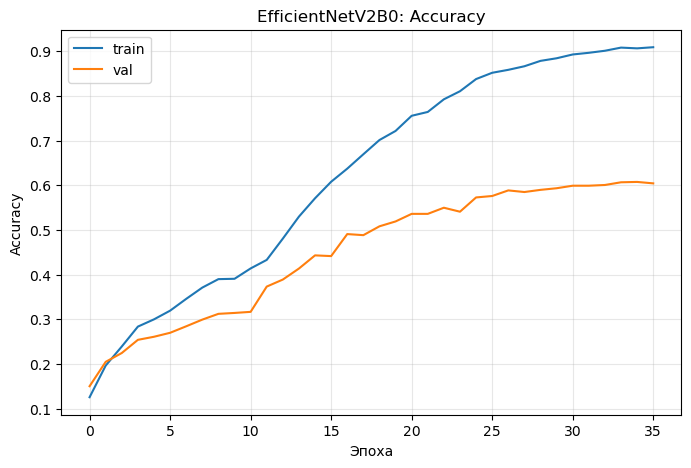

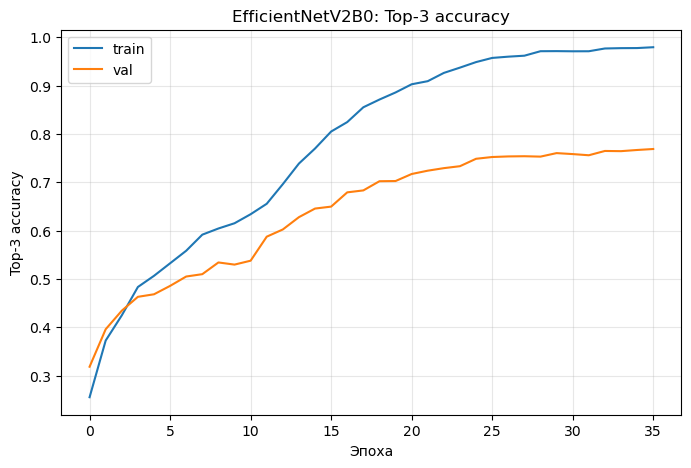

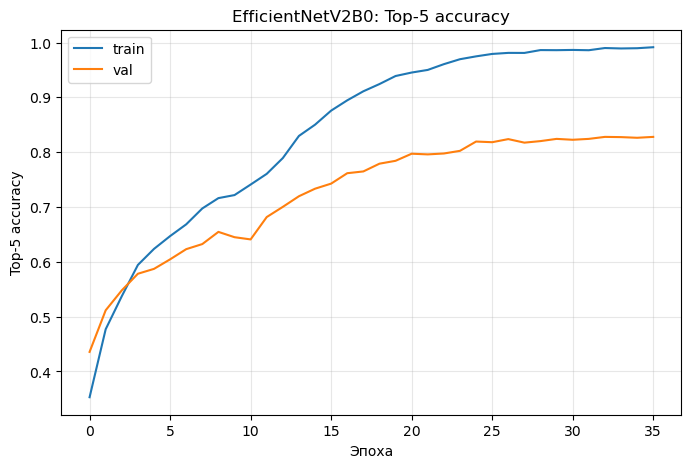

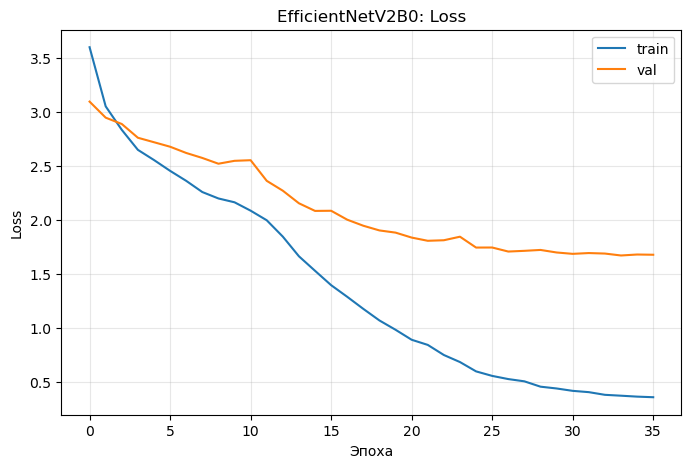

In [12]:
def merge_histories(*histories):
    merged = {}
    for history in histories:
        if history is None:
            continue
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

def plot_training_curves(history_dict, title="Обучение модели"):
    metrics = [
        ("accuracy", "val_accuracy", "Accuracy"),
        ("top3_accuracy", "val_top3_accuracy", "Top-3 accuracy"),
        ("top5_accuracy", "val_top5_accuracy", "Top-5 accuracy"),
        ("loss", "val_loss", "Loss"),
    ]

    for train_key, val_key, metric_name in metrics:
        if train_key not in history_dict or val_key not in history_dict:
            continue

        plt.figure(figsize=(8, 5))
        plt.plot(history_dict[train_key], label="train")
        plt.plot(history_dict[val_key], label="val")
        plt.title(f"{title}: {metric_name}")
        plt.xlabel("Эпоха")
        plt.ylabel(metric_name)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

history_all = merge_histories(hist_warmup, hist_ft)
plot_training_curves(history_all, title="EfficientNetV2B0")

## 8. Оценка на test и подробные метрики

Обычная accuracy не всегда достаточно информативна. Для 33 классов полезны:

- `top-3 accuracy`: правильная марка попала в 3 наиболее вероятных варианта;
- `top-5 accuracy`: правильная марка попала в 5 вариантов;
- precision/recall/F1 по каждому классу;
- confusion matrix.

In [13]:
best_tl_path = "models/effv2b0_best.keras"

if os.path.exists(best_tl_path):
    model_tl.load_weights(best_tl_path)
    print("Загружены лучшие веса:", best_tl_path)
else:
    print("Лучший checkpoint не найден, используются текущие веса модели.")

test_metrics = model_tl.evaluate(test_ds, verbose=0)
print("Метрики EfficientNetV2B0 на test:")
for name, value in zip(model_tl.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")

y_true = df_test["label_idx"].values
y_pred_proba = model_tl.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nПроверка top-k через sklearn:")
print("Top-3 accuracy:", top_k_accuracy_score(y_true, y_pred_proba, k=3, labels=np.arange(num_classes)))
print("Top-5 accuracy:", top_k_accuracy_score(y_true, y_pred_proba, k=5, labels=np.arange(num_classes)))

report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4,
    zero_division=0,
    output_dict=True,
)
report_df = pd.DataFrame(report).T
display(report_df)

Загружены лучшие веса: models/effv2b0_best.keras
Метрики EfficientNetV2B0 на test:
loss: 1.6482
compile_metrics: 0.6105
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step

Проверка top-k через sklearn:
Top-3 accuracy: 0.7583838383838384
Top-5 accuracy: 0.8185858585858586


,precision,recall,f1-score,support
Acura,0.677419,0.560000,0.613139,75.000000
Aston Martin,0.659794,0.853333,0.744186,75.000000
Audi,0.578947,0.586667,0.582781,75.000000
BMW,0.568966,0.440000,0.496241,75.000000
Bentley,0.670886,0.706667,0.688312,75.000000
Buick,0.552941,0.626667,0.587500,75.000000
Cadillac,0.604938,0.653333,0.628205,75.000000
Chevrolet,0.576923,0.400000,0.472441,75.000000
Chrysler,0.775000,0.826667,0.800000,75.000000
Dodge,0.559524,0.626667,0.591195,75.000000


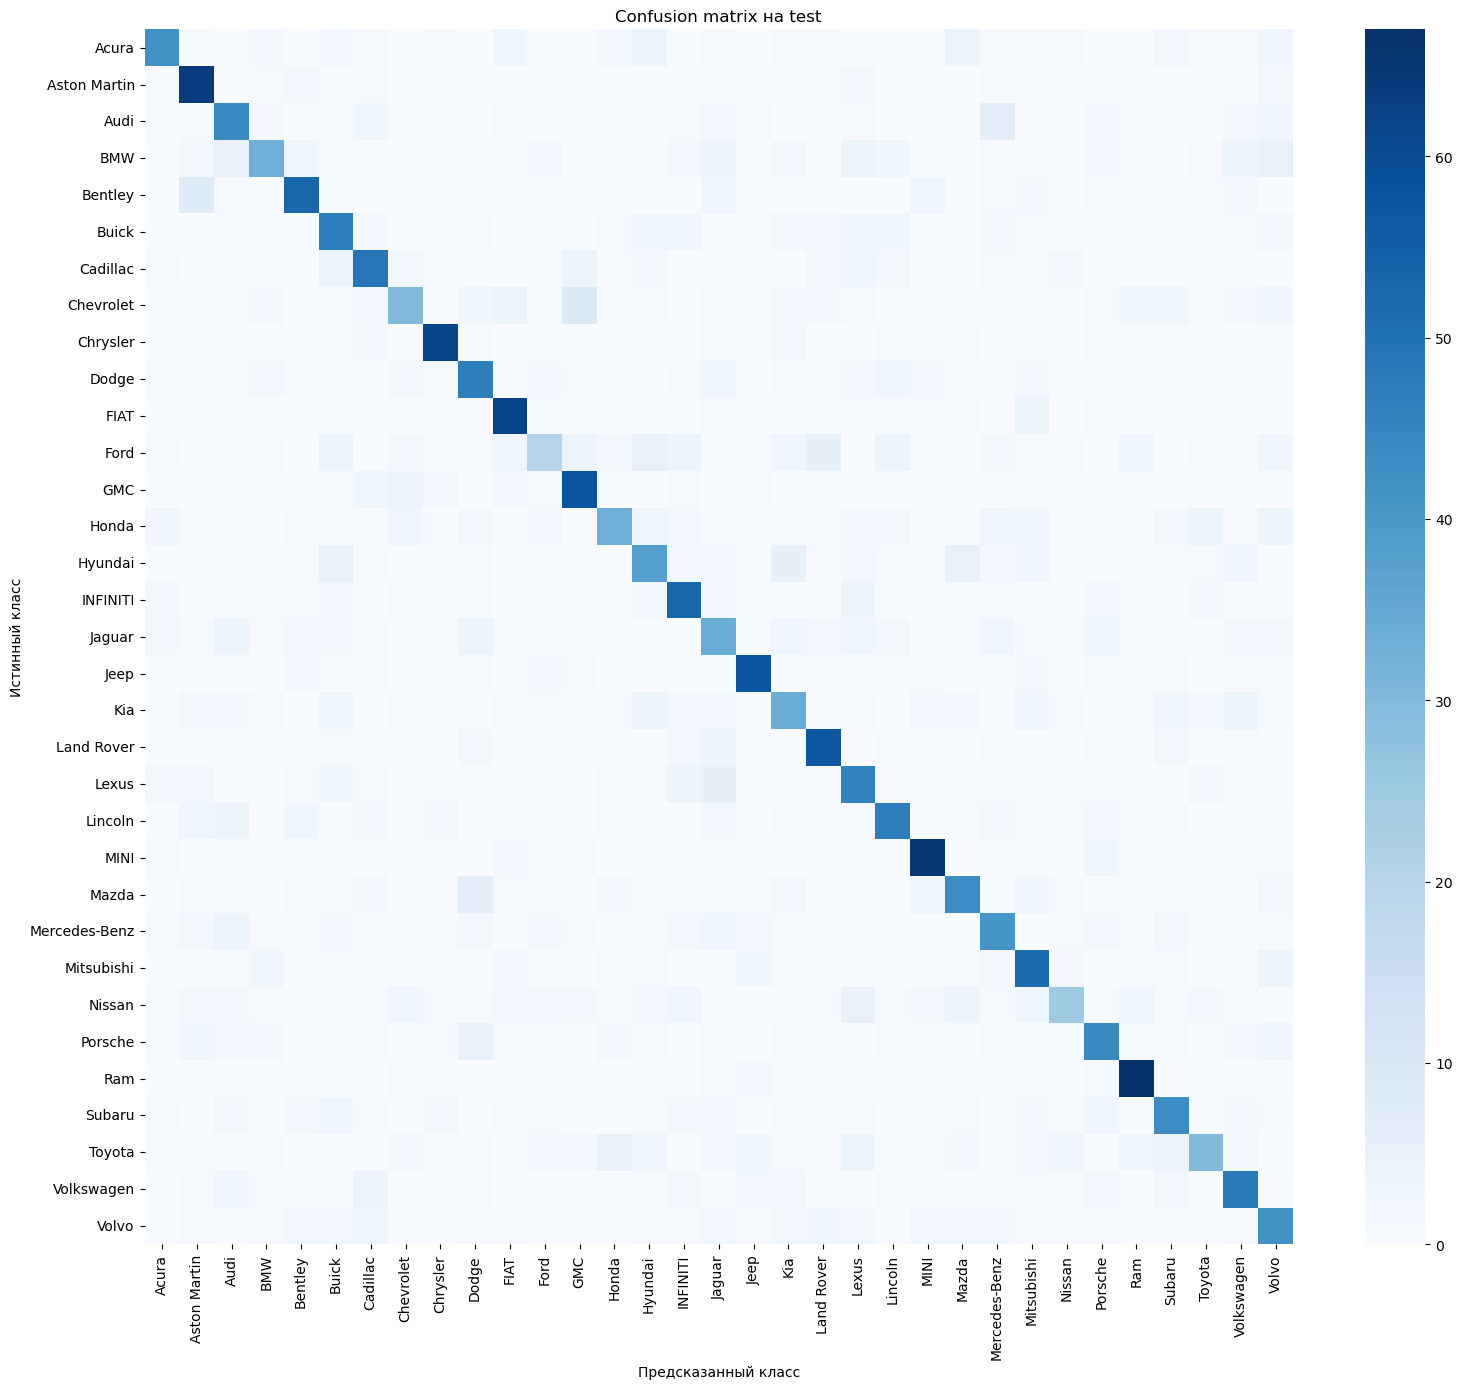

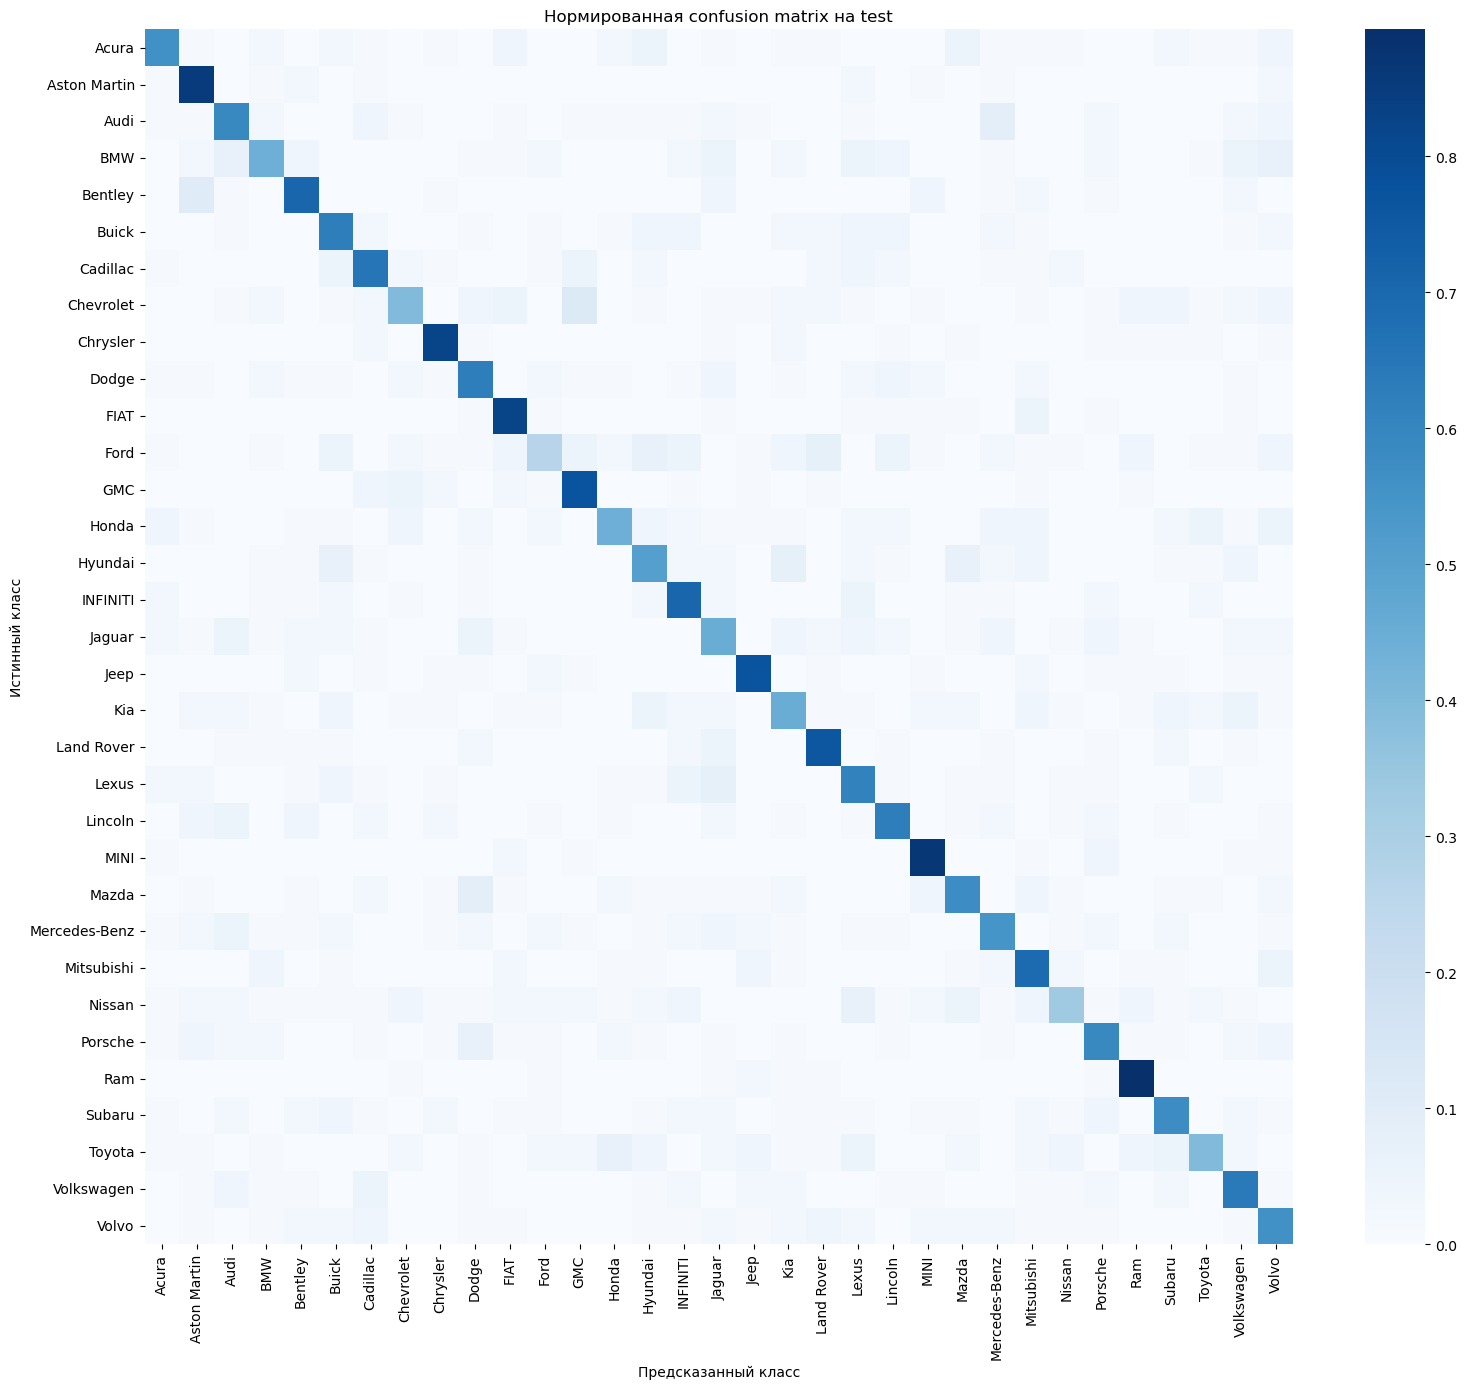

In [15]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    square=False,
    cbar=True,
)
plt.title("Confusion matrix на test")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Нормированная матрица показывает доли ошибок внутри каждого истинного класса.
cm_norm = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    square=False,
    cbar=True,
)
plt.title("Нормированная confusion matrix на test")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# Таблица самых частых пар ошибок.
error_pairs = []
for true_idx in range(num_classes):
    for pred_idx in range(num_classes):
        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
            error_pairs.append({
                "true_class": idx2class[true_idx],
                "pred_class": idx2class[pred_idx],
                "count": int(cm[true_idx, pred_idx]),
                "share_within_true_class": float(cm_norm[true_idx, pred_idx]),
            })

error_pairs_df = pd.DataFrame(error_pairs).sort_values(
    ["count", "share_within_true_class"],
    ascending=False,
)
display(error_pairs_df.head(30))

,true_class,pred_class,count,share_within_true_class
103,Chevrolet,GMC,9,0.120000
60,Bentley,Aston Martin,8,0.106667
40,Audi,Mercedes-Benz,7,0.093333
350,Mazda,Dodge,7,0.093333
170,Ford,Land Rover,6,0.080000
217,Hyundai,Kia,6,0.080000
316,Lexus,Jaguar,6,0.080000
45,BMW,Audi,5,0.066667
59,BMW,Volvo,5,0.066667
166,Ford,Hyundai,5,0.066667


## 9. Анализ ошибочных предсказаний

Ниже выводятся изображения, где модель ошиблась сильнее всего. Это помогает понять источник проблемы:

- визуально похожие марки;
- неправильные labels;
- слишком маленький или закрытый логотип;
- плохое качество изображения;
- доменный сдвиг между train и test.

66. true=Acura, pred=Honda, top5=[Honda: 1.00, Ford: 0.00, Mazda: 0.00, Chevrolet: 0.00, Kia: 0.00], path=/home/sm/Desktop/ml/CarBrandClassificationDataset/test/Acura/Acura_ILX_2014_28_16_110_15_4_70_55_179_39_FWD_5_4_4dr_rxS.jpg
1457. true=Land Rover, pred=Dodge, top5=[Dodge: 0.99, Acura: 0.00, Chevrolet: 0.00, Jaguar: 0.00, Lexus: 0.00], path=/home/sm/Desktop/ml/CarBrandClassificationDataset/test/Land Rover/Land Rover_Range Rover Sport_2014_92_21_510_50_8_78_70_191_14_4WD_5_4_SUV_CoZ.jpg
551. true=Chevrolet, pred=Land Rover, top5=[Land Rover: 0.98, Jeep: 0.01, Chevrolet: 0.00, Ford: 0.00, Lincoln: 0.00], path=/home/sm/Desktop/ml/CarBrandClassificationDataset/test/Chevrolet/Chevrolet_Blazer_1998_21_15_190_43_6_67_64_nan_16_RWD_4_2_SUV_fYG.jpg
879. true=Ford, pred=Ram, top5=[Ram: 0.97, GMC: 0.02, Cadillac: 0.00, Dodge: 0.00, Chevrolet: 0.00], path=/home/sm/Desktop/ml/CarBrandClassificationDataset/test/Ford/Ford_Super Duty F-250_2011_46_18_380_62_8_79_77_nan_nan_RWD_5_4_Pickup_Lwh.jpg
5

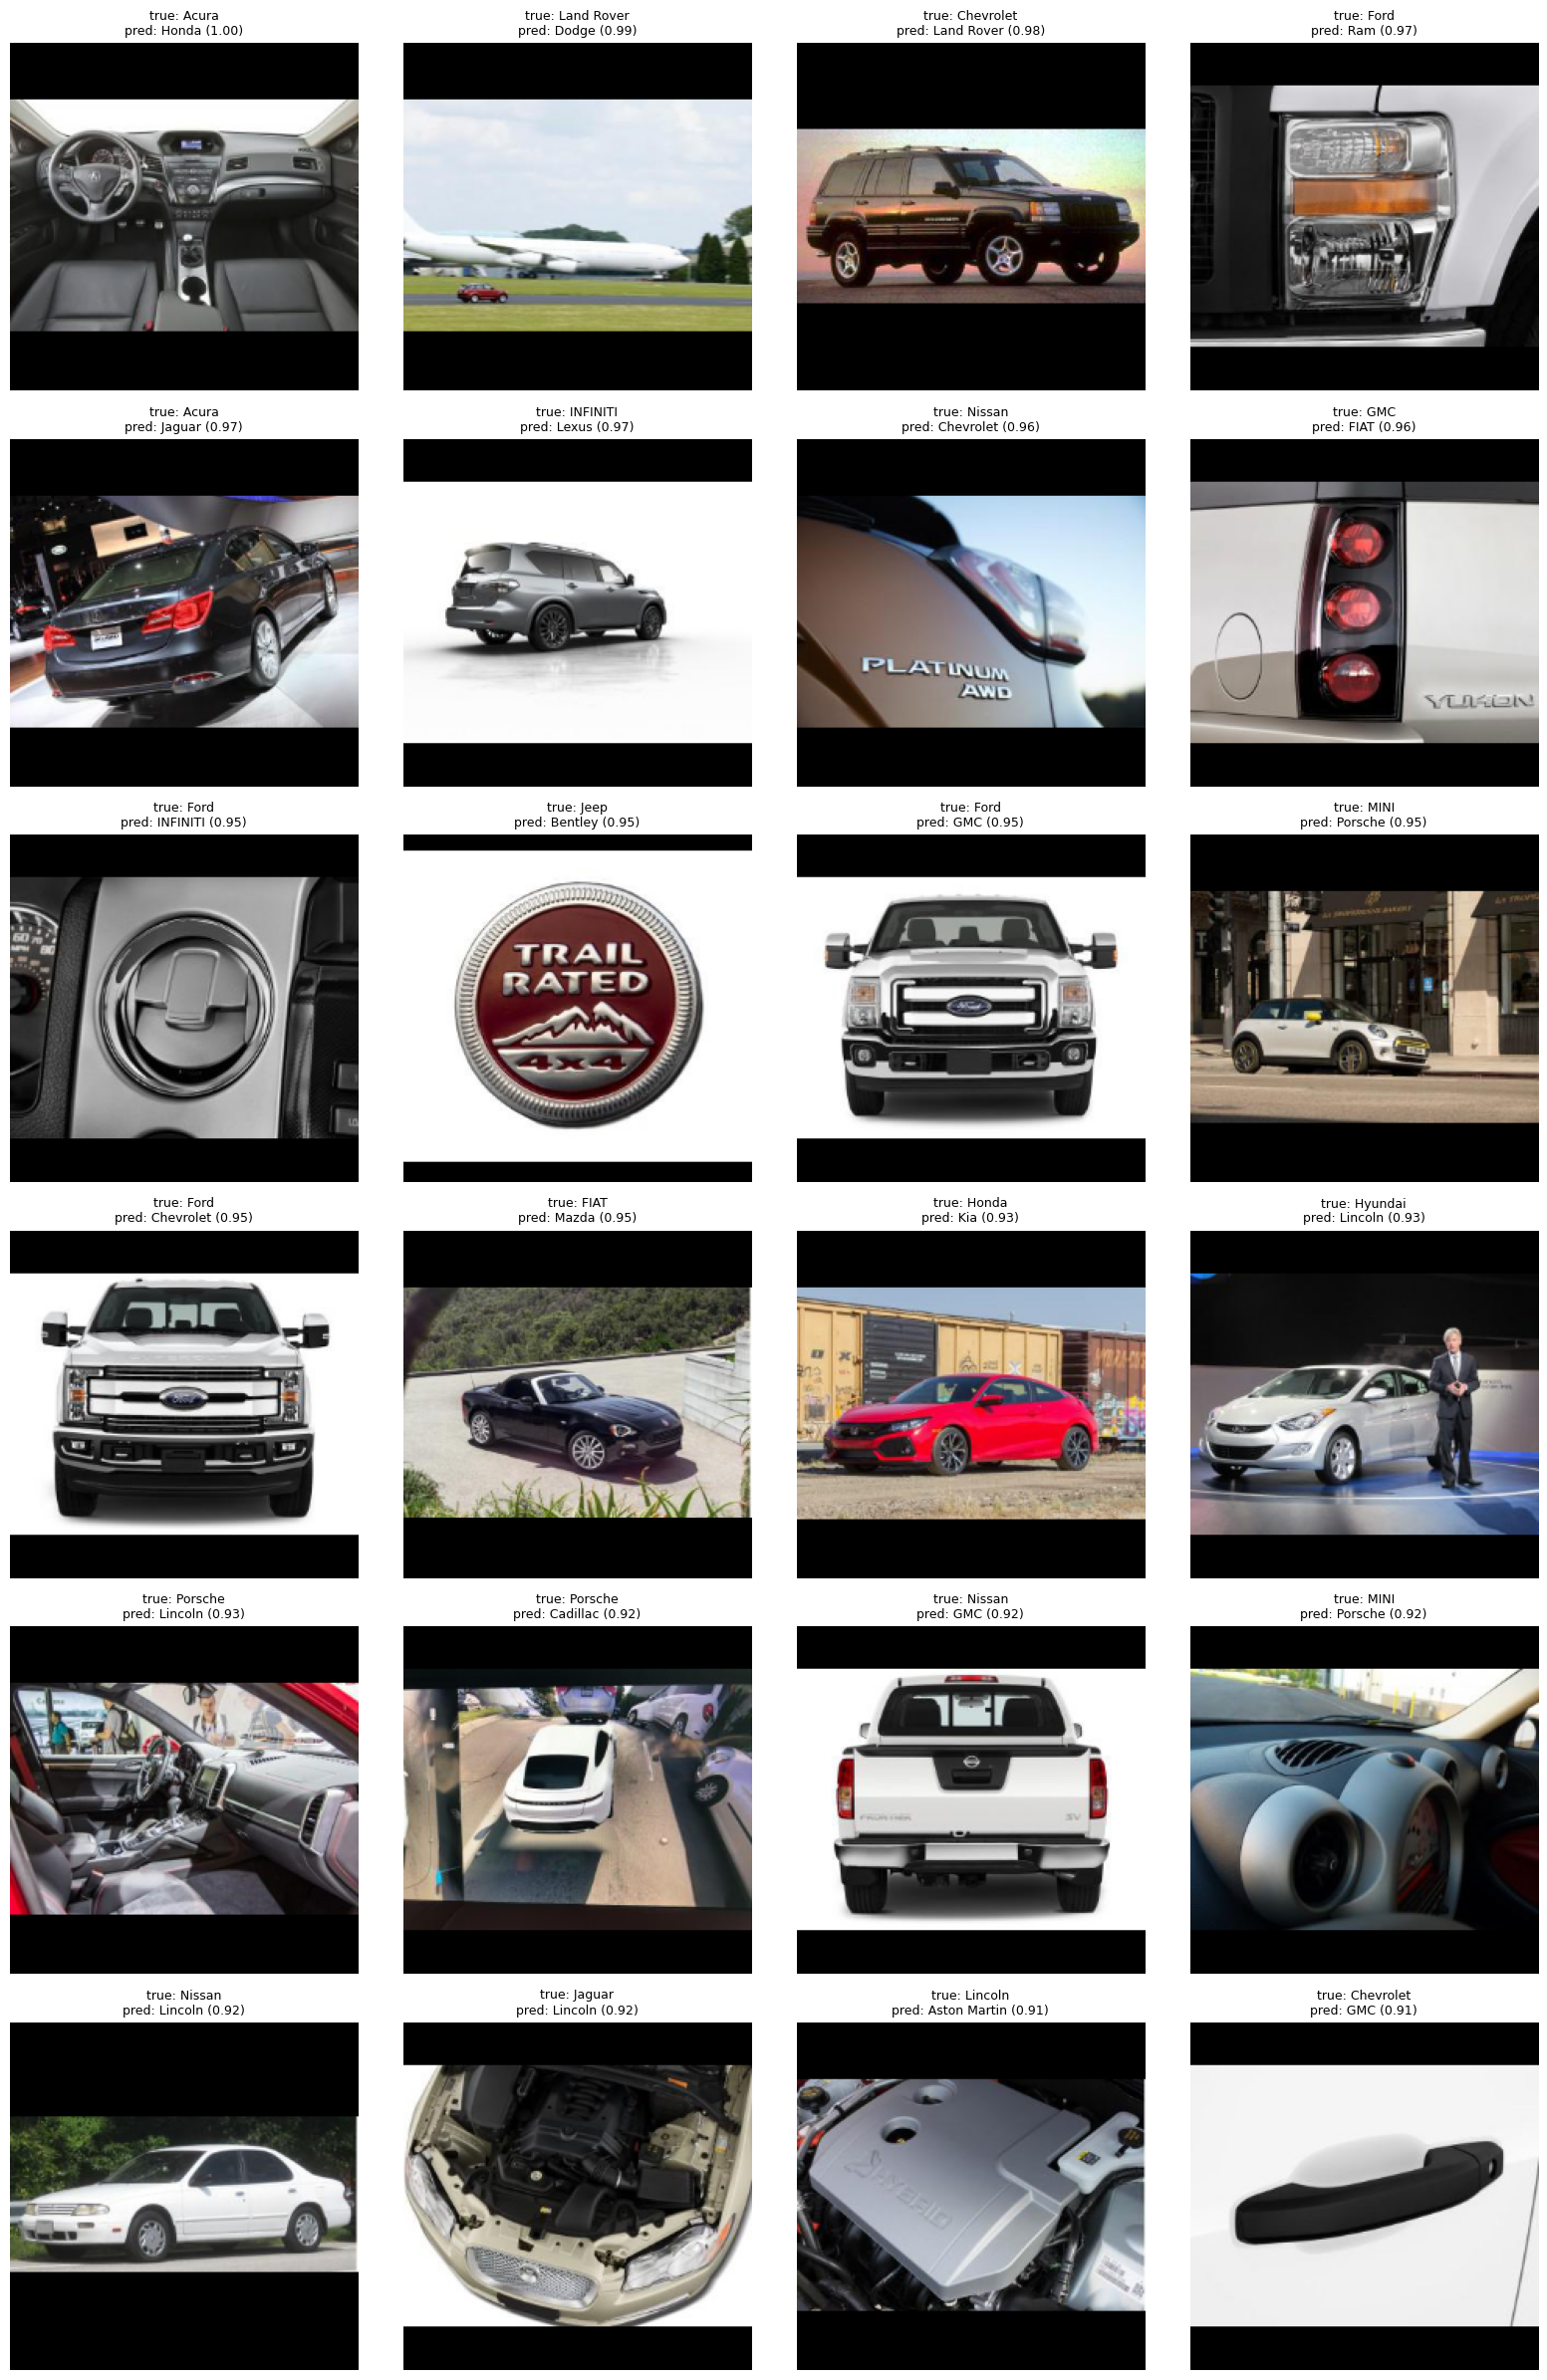

In [17]:
def show_misclassified_examples(df, y_true, y_pred, y_pred_proba, n=24):
    wrong_idx = np.where(y_true != y_pred)[0]
    if len(wrong_idx) == 0:
        print("Ошибок не найдено.")
        return

    # Уверенность модели в ошибочном предсказании.
    wrong_conf = y_pred_proba[wrong_idx, y_pred[wrong_idx]]
    order = wrong_idx[np.argsort(-wrong_conf)]
    selected = order[:n]

    cols = 4
    rows = int(np.ceil(len(selected) / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, idx in enumerate(selected, start=1):
        img = decode_image(df.iloc[idx]["path"]).numpy()

        true_name = idx2class[int(y_true[idx])]
        pred_name = idx2class[int(y_pred[idx])]
        conf = float(y_pred_proba[idx, y_pred[idx]])

        top5 = np.argsort(-y_pred_proba[idx])[:5]
        top5_text = ", ".join([f"{idx2class[int(j)]}: {y_pred_proba[idx, j]:.2f}" for j in top5])

        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"true: {true_name}\npred: {pred_name} ({conf:.2f})", fontsize=9)
        print(f"{idx}. true={true_name}, pred={pred_name}, top5=[{top5_text}], path={df.iloc[idx]['path']}")

    plt.tight_layout()
    plt.show()

show_misclassified_examples(df_test, y_true, y_pred, y_pred_proba, n=24)

Общий вывод по работе: работает распознавание хороших ракурсов, но с учетом того что многие машины отличаются друг от друга по сути только шильдиком, тут тоже есть ошибки.

Отвратительную роль играют выбросы - фото салона, дисков, брошюрок, 'машина на фоне самолета', 'три машины где-то далеко' и т.п. - они не только идут методом случайного угадывания, но еще и портят общее обучение модели.

К сожалению выбросить их просто так не получиться 
- они все-таки часть датасета и составляют значительную его часть
- есть редкие модели - винтажные хонды, астон мартины и т.д. у них тоже всего несколько фоток в датасете и при автоматической чистке мы тоже выкинем